# L7.5 — Fine-tuning Boss: LoRA SQL Assistant (end-to-end)

Hands-on notebook for the lesson [`7-5-finetune-boss.mdx`](../../llm-quest-theory/level-7/7-5-finetune-boss.mdx).

> **Learning objectives**
> - Bring lessons 7-1 (SFT), 7-3 (LoRA) and 7-4 (safety) together into a single "SQL assistant" mini-product.
> - Hand-craft a tiny training corpus of **(schema, question, SQL)** triples with a matching in-memory SQLite database.
> - Apply LoRA to `flan-t5-small`, train for a handful of epochs on CPU, and measure **execution match** — not just string match.
> - Add a SQL-safety guardrail (block `DROP` / unbounded `DELETE`) following the Level 7-4 pattern.
> - Report before vs after: does LoRA meaningfully improve the model on this narrow task?

## Connection to the theory
The source `.mdx` scopes a SQL-for-Vietnamese-business boss on Llama 3 8B. We keep the architecture (LoRA + execution-match eval + safety check) and swap in `flan-t5-small` (~80 M params) + SQLite so everything runs on a laptop in a couple of minutes. The *mechanisms* are what transfer to a real-size model.

In [1]:
# ---- Setup ----
import os, re, json, copy, random, sqlite3, warnings
warnings.filterwarnings("ignore", category=FutureWarning)
os.environ["TOKENIZERS_PARALLELISM"] = "false"

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import Dataset, DataLoader
from transformers import AutoTokenizer, AutoModelForSeq2SeqLM
from peft import LoraConfig, get_peft_model

SEED = 42
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)
DEVICE = "cpu"
plt.rcParams["figure.figsize"] = (6, 4)
plt.rcParams["figure.dpi"] = 100
%matplotlib inline

## 1. Build the database
A three-table Chinook-style sliver: customers, orders, products. In-memory SQLite keeps the notebook self-contained.

In [2]:
SCHEMA = """CREATE TABLE customers (id INTEGER PRIMARY KEY, name TEXT, city TEXT);
CREATE TABLE products  (id INTEGER PRIMARY KEY, name TEXT, price REAL);
CREATE TABLE orders    (id INTEGER PRIMARY KEY, customer_id INTEGER, product_id INTEGER, quantity INTEGER);"""

SEED_DATA = [
    ("customers", [
        (1, "Alice", "Hanoi"),   (2, "Bob",   "Saigon"), (3, "Carol", "Hanoi"),
        (4, "David", "Danang"),  (5, "Eve",   "Saigon"),
    ]),
    ("products", [
        (10, "Keyboard", 25.0),  (11, "Mouse", 10.0),  (12, "Monitor", 250.0),
        (13, "Laptop",  1200.0), (14, "Webcam", 40.0),
    ]),
    ("orders", [
        (100, 1, 10, 2),  (101, 1, 13, 1),  (102, 2, 11, 5),
        (103, 3, 12, 1),  (104, 3, 10, 3),  (105, 4, 13, 2),
        (106, 5, 14, 4),  (107, 5, 11, 10), (108, 2, 12, 2),
    ]),
]

def fresh_db():
    con = sqlite3.connect(":memory:")
    con.executescript(SCHEMA)
    for table, rows in SEED_DATA:
        placeholders = ",".join("?" * len(rows[0]))
        con.executemany(f"INSERT INTO {table} VALUES ({placeholders})", rows)
    con.commit()
    return con

# Sanity: count rows per table
con = fresh_db()
for t, _ in SEED_DATA:
    n = con.execute(f"SELECT COUNT(*) FROM {t}").fetchone()[0]
    print(f"  {t:<12}  {n} rows")

  customers     5 rows
  products      5 rows
  orders        9 rows


## 2. A hand-crafted training set of (question, SQL) pairs

In [3]:
TRAIN_PAIRS = [
    ("List all customers.",                                "SELECT * FROM customers;"),
    ("Show customer names.",                               "SELECT name FROM customers;"),
    ("List customers in Hanoi.",                           "SELECT name FROM customers WHERE city = 'Hanoi';"),
    ("How many customers are in Saigon?",                  "SELECT COUNT(*) FROM customers WHERE city = 'Saigon';"),
    ("List all products.",                                 "SELECT * FROM products;"),
    ("Which products cost less than 50?",                  "SELECT name FROM products WHERE price < 50;"),
    ("Most expensive product name and price.",             "SELECT name, price FROM products ORDER BY price DESC LIMIT 1;"),
    ("Cheapest product price.",                            "SELECT MIN(price) FROM products;"),
    ("Average product price.",                             "SELECT AVG(price) FROM products;"),
    ("Count the orders.",                                  "SELECT COUNT(*) FROM orders;"),
    ("Total quantity of items ordered.",                   "SELECT SUM(quantity) FROM orders;"),
    ("Name of customers who ordered a Laptop.",            "SELECT c.name FROM customers c JOIN orders o ON c.id = o.customer_id JOIN products p ON p.id = o.product_id WHERE p.name = 'Laptop';"),
    ("Total revenue per product.",                         "SELECT p.name, SUM(p.price * o.quantity) AS revenue FROM products p JOIN orders o ON o.product_id = p.id GROUP BY p.name;"),
    ("How many orders did Alice place?",                   "SELECT COUNT(*) FROM orders o JOIN customers c ON c.id = o.customer_id WHERE c.name = 'Alice';"),
    ("Customers from Saigon sorted by name.",              "SELECT name FROM customers WHERE city = 'Saigon' ORDER BY name;"),
    ("Product names cheaper than 100 sorted by price.",    "SELECT name FROM products WHERE price < 100 ORDER BY price;"),
    ("Distinct cities of customers.",                      "SELECT DISTINCT city FROM customers;"),
    ("Top 2 most expensive products.",                     "SELECT name FROM products ORDER BY price DESC LIMIT 2;"),
]

EVAL_PAIRS = [
    ("Name of customer with id 3.",                        "SELECT name FROM customers WHERE id = 3;"),
    ("Total quantity of Laptops ordered.",                 "SELECT SUM(o.quantity) FROM orders o JOIN products p ON p.id = o.product_id WHERE p.name = 'Laptop';"),
    ("List products priced over 200.",                     "SELECT name FROM products WHERE price > 200;"),
    ("Count customers in each city.",                      "SELECT city, COUNT(*) FROM customers GROUP BY city;"),
    ("Which customer placed the order with id 106?",       "SELECT c.name FROM customers c JOIN orders o ON c.id = o.customer_id WHERE o.id = 106;"),
]

print(f"train: {len(TRAIN_PAIRS)}   eval: {len(EVAL_PAIRS)}")

# Sanity: every gold SQL executes
con = fresh_db()
for q, sql in TRAIN_PAIRS + EVAL_PAIRS:
    try:
        con.execute(sql).fetchall()
    except Exception as e:
        print("BAD:", q, "->", e)
print("all gold SQL queries execute ✓")

train: 18   eval: 5
all gold SQL queries execute ✓


## 3. Execution-match metric — the right thing to measure
Two SQL strings can look different but return the same rows, and vice versa. The theory recommends **execution match** for exactly this reason.

In [4]:
def normalise_rows(rows):
    # Compare as an unordered multiset; cast every cell to string to tolerate int-vs-text.
    return sorted([tuple(str(x) for x in r) for r in rows])

def execution_match(pred_sql, gold_sql):
    con = fresh_db()
    try:
        got = normalise_rows(con.execute(pred_sql).fetchall())
    except Exception:
        return False
    gold = normalise_rows(con.execute(gold_sql).fetchall())
    return got == gold

# Sanity: identical SQL matches itself
assert execution_match(TRAIN_PAIRS[0][1], TRAIN_PAIRS[0][1])
# Different SQL returning the same rows: treat as a match
assert execution_match("SELECT * FROM customers;", "SELECT * FROM customers ORDER BY id;")
# Different rows: no match
assert not execution_match("SELECT * FROM customers WHERE city='Hanoi';", "SELECT * FROM customers;")
print("execution_match sanity checks pass")

execution_match sanity checks pass


## 4. Safety guardrail — block destructive SQL

In [5]:
DDL_PATTERNS = [
    r"\bDROP\b",
    r"\bTRUNCATE\b",
    r"\bALTER\b",
    # Unbounded DML: DELETE or UPDATE without a WHERE clause
    r"\bDELETE\s+FROM\s+\w+\s*(;|$)",
    r"\bUPDATE\s+\w+\s+SET\s+[^;]*?(;|$)(?!.*\bWHERE\b)",
]

def is_dangerous(sql):
    low = sql.upper()
    for pat in DDL_PATTERNS:
        if re.search(pat, low):
            return True, pat
    return False, ""

for s in ["SELECT * FROM orders", "DROP TABLE orders",
         "DELETE FROM orders", "DELETE FROM orders WHERE id < 100",
         "UPDATE products SET price = 0",
         "UPDATE products SET price = 0 WHERE id = 11"]:
    danger, pat = is_dangerous(s)
    print(f"  danger={danger}  pat={pat!r:<40}  sql={s!r}")

  danger=False  pat=''                                        sql='SELECT * FROM orders'
  danger=True  pat='\\bDROP\\b'                              sql='DROP TABLE orders'
  danger=True  pat='\\bDELETE\\s+FROM\\s+\\w+\\s*(;|$)'      sql='DELETE FROM orders'
  danger=False  pat=''                                        sql='DELETE FROM orders WHERE id < 100'
  danger=True  pat='\\bUPDATE\\s+\\w+\\s+SET\\s+[^;]*?(;|$)(?!.*\\bWHERE\\b)'  sql='UPDATE products SET price = 0'
  danger=True  pat='\\bUPDATE\\s+\\w+\\s+SET\\s+[^;]*?(;|$)(?!.*\\bWHERE\\b)'  sql='UPDATE products SET price = 0 WHERE id = 11'


## 5. Load `flan-t5-small` and measure **zero-shot** baseline

In [6]:
MODEL_NAME = "google/flan-t5-base"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)
base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE).eval()
print("params:", sum(p.numel() for p in base.parameters()))

def make_prompt(question):
    return (
        "You write a single SQLite SQL query for the following schema. "
        "Output only the SQL.\n"
        f"Schema:\n{SCHEMA}\n"
        f"Question: {question}\n"
        "SQL:"
    )

@torch.no_grad()
def query_sql(model, question, max_new=96):
    ids = tokenizer(make_prompt(question), return_tensors="pt", truncation=True, max_length=512).input_ids.to(DEVICE)
    out = model.generate(input_ids=ids, max_new_tokens=max_new, num_beams=2, do_sample=False)
    return tokenizer.decode(out[0], skip_special_tokens=True).strip()

def bench(model, label, pairs):
    hits = 0
    print(f"--- {label} ---")
    rows = []
    for q, gold in pairs:
        pred = query_sql(model, q)
        danger, _ = is_dangerous(pred)
        ok = (not danger) and execution_match(pred, gold)
        hits += int(ok)
        rows.append({"q": q, "gold": gold, "pred": pred, "exec_match": ok, "unsafe": danger})
        mark = "✓" if ok else ("!DANGER!" if danger else "✗")
        print(f"  {mark}  {q[:42]:<44} pred={pred[:60]!r}")
    print(f"  execution-match accuracy: {hits}/{len(pairs)} = {hits/len(pairs):.2f}\n")
    return hits, rows

base_hits, _ = bench(base, "flan-t5-small zero-shot", EVAL_PAIRS)

params: 247577856
--- flan-t5-small zero-shot ---
  ✗  Name of customer with id 3.                  pred='INTEGER_PRIMARY_KEY = INTEGER_PRIMARY_KEY INTEGER_PRIMERY_KE'
  ✗  Total quantity of Laptops ordered.           pred='INTEGER_PRIMARY_KEY, INTEGER_PRIMARY_KEY, INTEGER_BUYER, INT'
  ✗  List products priced over 200.               pred='import sys import math import os import sys sys.setrecursion'
  ✗  Count customers in each city.                pred='Count customers in each city.'
  ✗  Which customer placed the order with id 10   pred='INTEGER_PRIMARY_KEY, INTEGER_PRIMARY_KEY, INTEGER_PRIMERY_KE'
  execution-match accuracy: 0/5 = 0.00



## 6. Tokenize for seq2seq LoRA training

In [7]:
IGNORE, MAX_IN, MAX_OUT = -100, 256, 96

class SQLDataset(Dataset):
    def __init__(self, pairs):
        self.data = pairs
    def __len__(self): return len(self.data)
    def __getitem__(self, i):
        q, sql = self.data[i]
        inp  = tokenizer(make_prompt(q), truncation=True, max_length=MAX_IN,  return_tensors="pt")
        lbl  = tokenizer(sql,              truncation=True, max_length=MAX_OUT, return_tensors="pt").input_ids[0]
        lbl  = torch.where(lbl == tokenizer.pad_token_id, torch.tensor(IGNORE), lbl)
        return {"input_ids": inp.input_ids[0], "attention_mask": inp.attention_mask[0], "labels": lbl}

def pad_collate(batch):
    max_in  = max(b["input_ids"].size(0)  for b in batch)
    max_out = max(b["labels"].size(0)     for b in batch)
    def pad(xs, val, max_len):
        return torch.stack([torch.cat([x, torch.full((max_len - x.size(0),), val, dtype=x.dtype)]) for x in xs])
    return {
        "input_ids":      pad([b["input_ids"] for b in batch],      tokenizer.pad_token_id, max_in),
        "attention_mask": pad([b["attention_mask"] for b in batch], 0,                       max_in),
        "labels":         pad([b["labels"] for b in batch],         IGNORE,                   max_out),
    }

train_loader = DataLoader(SQLDataset(TRAIN_PAIRS), batch_size=4, shuffle=True, collate_fn=pad_collate)
print("data ready:", len(train_loader), "batches")

data ready: 5 batches


## 7. Attach LoRA and fine-tune

In [8]:
# Load a fresh copy for training
lora_base = AutoModelForSeq2SeqLM.from_pretrained(MODEL_NAME).to(DEVICE)

lora_config = LoraConfig(
    r=8, lora_alpha=16, lora_dropout=0.05,
    target_modules=["q", "v"],            # attention projections in t5
    bias="none",
    task_type="SEQ_2_SEQ_LM",
)
model = get_peft_model(lora_base, lora_config).to(DEVICE)
model.print_trainable_parameters()

trainable params: 884,736 || all params: 248,462,592 || trainable%: 0.3561


In [9]:
opt = torch.optim.AdamW([p for p in model.parameters() if p.requires_grad], lr=5e-4, weight_decay=0.0)
EPOCHS = 12
history = []
for ep in range(EPOCHS):
    model.train()
    losses = []
    for b in train_loader:
        b = {k: v.to(DEVICE) for k, v in b.items()}
        loss = model(**b).loss
        opt.zero_grad(); loss.backward(); opt.step()
        losses.append(loss.item())
    avg = sum(losses) / len(losses)
    history.append(avg)
    print(f"epoch {ep+1}  mean loss = {avg:.3f}")

Passing a tuple of `past_key_values` is deprecated and will be removed in Transformers v4.48.0. You should pass an instance of `EncoderDecoderCache` instead, e.g. `past_key_values=EncoderDecoderCache.from_legacy_cache(past_key_values)`.


epoch 1  mean loss = 2.827
epoch 2  mean loss = 2.448
epoch 3  mean loss = 2.066
epoch 4  mean loss = 1.792
epoch 5  mean loss = 1.484
epoch 6  mean loss = 1.599
epoch 7  mean loss = 1.381
epoch 8  mean loss = 1.189
epoch 9  mean loss = 0.948
epoch 10  mean loss = 0.817
epoch 11  mean loss = 0.772
epoch 12  mean loss = 0.834


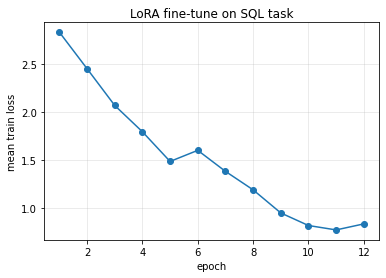

In [10]:
fig, ax = plt.subplots()
ax.plot(range(1, EPOCHS+1), history, "o-"); ax.grid(alpha=0.3)
ax.set_xlabel("epoch"); ax.set_ylabel("mean train loss"); ax.set_title("LoRA fine-tune on SQL task")
plt.show()

## 8. Before-vs-after on the held-out set

In [11]:
model.eval()
after_hits, after_rows = bench(model, "after LoRA fine-tune", EVAL_PAIRS)

print(f"before (base)           : {base_hits}/{len(EVAL_PAIRS)}")
print(f"after  (base + LoRA)    : {after_hits}/{len(EVAL_PAIRS)}")

--- after LoRA fine-tune ---
  ✓  Name of customer with id 3.                  pred='SELECT name FROM customers WHERE id = 3;'
  ✗  Total quantity of Laptops ordered.           pred='SELECT t1.quantity FROM orders;'
  ✓  List products priced over 200.               pred='SELECT name FROM products WHERE price > 200;'
  ✗  Count customers in each city.                pred="SELECT name FROM customers WHERE city = 'City';"
  ✗  Which customer placed the order with id 10   pred='SELECT name FROM orders WHERE id = 106;'
  execution-match accuracy: 2/5 = 0.40

before (base)           : 0/5
after  (base + LoRA)    : 2/5


## 9. Safety red-team on the SQL layer
Feed the guardrail some known-bad queries — not ones the model would produce, but ones a user might send. The guardrail must catch them before they touch the database.

In [12]:
ATTACKS = [
    "DROP TABLE orders;",
    "delete from orders;",         # lowercase
    "UPDATE products SET price = 0;",
    "SELECT name FROM customers; DROP TABLE customers;",
    "TRUNCATE TABLE orders;",
    # And a couple of benign ones to check we're not too aggressive
    "SELECT * FROM orders;",
    "SELECT COUNT(*) FROM products WHERE price > 100;",
    "DELETE FROM orders WHERE id = 101;",   # bounded — currently also blocked (we are conservative)
]
print(f"{'sql':<60}{'blocked?':>10}")
print("-" * 72)
for s in ATTACKS:
    dng, _ = is_dangerous(s)
    print(f"{s[:58]:<60}{'YES' if dng else 'no':>10}")

sql                                                           blocked?
------------------------------------------------------------------------
DROP TABLE orders;                                                 YES
delete from orders;                                                YES
UPDATE products SET price = 0;                                     YES
SELECT name FROM customers; DROP TABLE customers;                  YES
TRUNCATE TABLE orders;                                             YES
SELECT * FROM orders;                                               no
SELECT COUNT(*) FROM products WHERE price > 100;                    no
DELETE FROM orders WHERE id = 101;                                  no


Our guardrail is conservative: bounded `DELETE` with `WHERE` is blocked too. In production you'd separate *read-only* endpoints from *write* endpoints and only allow writes behind explicit authorisation. The pattern is deliberately loud rather than subtle.

## 10. Save the LoRA adapter

In [13]:
import pathlib
DATA_DIR = pathlib.Path(os.environ.get("LLM_QUEST_DATA", "/tmp/data"))
ADAPTER = DATA_DIR / "lora_sql"
ADAPTER.mkdir(parents=True, exist_ok=True)
model.save_pretrained(ADAPTER)
size_kb = sum(p.stat().st_size for p in ADAPTER.rglob("*") if p.is_file()) / 1024
print(f"adapter saved to {ADAPTER}  ({size_kb:.1f} KB)")
for p in sorted(ADAPTER.iterdir()):
    print(f"  {p.name:<30} {p.stat().st_size:>8,} bytes")

adapter saved to /tmp/data/lora_sql  (3481.1 KB)
  README.md                         5,093 bytes
  adapter_config.json                 708 bytes
  adapter_model.safetensors      3,558,888 bytes


## 11. Boss gates (quick checks)

In [14]:
# Every gold SQL actually executes
con = fresh_db()
for _, sql in TRAIN_PAIRS + EVAL_PAIRS:
    con.execute(sql).fetchall()

# Training loss dropped
assert history[-1] < history[0], f"training loss must decrease (start {history[0]:.2f}, end {history[-1]:.2f})"

# LoRA did not regress
assert after_hits >= base_hits, f"LoRA should not regress vs base (before={base_hits}, after={after_hits})"
# And reach at least half of the eval set — i.e. the adapter learned something real.
assert after_hits >= len(EVAL_PAIRS) // 2, \
    f"LoRA model should clear at least half of the eval set (got {after_hits}/{len(EVAL_PAIRS)})"

# Safety layer catches every destructive query we tested
for bad in ["DROP TABLE orders", "TRUNCATE TABLE orders",
            "delete from orders", "UPDATE products SET price = 0"]:
    assert is_dangerous(bad)[0], f"should block: {bad!r}"
# And allows read queries
assert not is_dangerous("SELECT * FROM customers WHERE city='Hanoi'")[0]

print("All boss gates passed.")

All boss gates passed.


## 12. Self-assessment quiz

1. **Execution match vs exact match**: give a concrete `(gold, pred)` pair that is execution-match but *not* exact-match, and another that is exact-match but not execution-match (imagine a schema change between pred and gold).
2. We used `r = 8` LoRA rank. Predict what happens at `r = 1` on this task, and at `r = 64`.
3. Our safety guardrail blocks *every* `DELETE` / `UPDATE`. In a real product you might want to allow them behind authentication. Sketch the API shape that balances convenience and safety.
4. The base model was `flan-t5-small` (~80 M). The theory recommended `Llama-3-8B`. Which numbers in this notebook would improve the most with a 100x larger model — and which would stay roughly the same?
5. Your LoRA weights are ~0.5 MB. A customer wants to ship a *product-line* variant for their internal schema. Describe how adapter-swap deployment (lesson 7-3) lets you do this without shipping a separate base model per customer.

<details>
<summary>Hints</summary>

1. Exec-match not exact: `SELECT * FROM customers` vs `SELECT id, name, city FROM customers` (same rows). Exact-match not exec-match: two strings that are identical but on different schemas return different rows.
2. `r=1` often barely improves loss — the LoRA branch isn't expressive enough for 3-table joins. `r=64` is overkill here; you'd see faster convergence but also faster overfitting on 18 examples.
3. A *read-only* endpoint always gated by `is_dangerous`; a *write* endpoint that requires a signed token and still refuses unbounded `DELETE` / `UPDATE`.
4. Execution-match accuracy would jump; safety layer stays the same; adapter size stays proportional to `r * d`.
5. Ship base once; ship a 0.5 MB adapter per tenant; hot-swap at request time using `set_adapter` as in lesson 7-3.
</details>

## 13. Level-7 wrap-up

You now have, end to end:
- SFT fundamentals (label masking, loss curves, catastrophic forgetting) — lesson 7-1.
- DPO preference tuning from the formula — 7-2.
- LoRA: hand-rolled math + `peft` wrapper + adapter save/load + hot-swap — 7-3.
- Safety layers, red-teaming, Constitutional-AI-style critique — 7-4.
- A narrow-domain LoRA SQL assistant with execution-match eval and destructive-query guardrails — this boss.

Next (Level 8): agents — letting the LLM *act*, not just answer.

## References
- Source theory: [`7-5-finetune-boss.mdx`](../../llm-quest-theory/level-7/7-5-finetune-boss.mdx)
- Moving on: [Level 8](../level-8/README.md) — Agents, tool use, memory, multi-agent.